# 07 (local) - Evaluate the LoRA meta-model on the test set

Local-PC variant of `07_evaluate_ensemble.ipynb` for an **RTX 3060 12GB**, Ryzen 5 7500F, 32GB RAM.

Same evaluation as the Colab notebook (CPU fusion baselines + 4-bit Gemma-2-9B-it LoRA / optional zero-shot), with VRAM-safe defaults:

- repo/scratch paths on this machine (no Google Drive)
- fp16 4-bit load + `max_memory` GPU headroom
- `INFER_BATCH=1` (batch 4 OOMs on 12GB)
- zero-shot `max_length` matches training (800), not 2048
- writes `*_local` metric/plot files so Colab artifacts are not overwritten

Copy `tm_research/ensemble/artifacts/` from the Colab run first (especially `lora_adapter/`). Install CUDA PyTorch *before* the `%pip` cell. If `bitsandbytes` fails on native Windows, run this notebook in WSL2.


In [1]:
# Do not pip-install torch here — that can replace a CUDA build with CPU torch.
# Once: pip install torch --index-url https://download.pytorch.org/whl/cu124
# Double quotes: Windows pip treats single-quoted 'transformers>=4.44' as a literal name.
%pip install -q "transformers>=4.44" "peft>=0.11" "bitsandbytes>=0.43" accelerate datasets scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys, json, re
from pathlib import Path

# --- local machine ---
REPO_ROOT = r'F:\GitHub\topicmodeling'
TMP_ROOT = r'F:\GitHub\topicmodeling\.ensemble_tmp'

# 12GB VRAM knobs (RTX 3060)
INFER_BATCH = 1
LOCAL_ZS_MAX_LEN = 800
GPU_MAX_MEMORY = '10GiB'
CPU_MAX_MEMORY = '20GiB'
RUN_ZERO_SHOT = True  # set False if VRAM is tight after the LoRA cell

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

repo_path = Path(REPO_ROOT)
if not (repo_path / 'tm_research').is_dir():
    here = Path.cwd().resolve()
    while here.name != 'tm_research' and here.parent != here:
        here = here.parent
    if here.name == 'tm_research':
        repo_path = here.parent
        REPO_ROOT = str(repo_path)
        TMP_ROOT = str(repo_path / '.ensemble_tmp')

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

_env_path = Path(REPO_ROOT) / 'tm_research' / '.env'
if _env_path.is_file():
    for _line in _env_path.read_text(encoding='utf-8').splitlines():
        _line = _line.strip()
        if not _line or _line.startswith('#') or '=' not in _line:
            continue
        _k, _, _v = _line.partition('=')
        _k, _v = _k.strip(), _v.strip().strip('"').strip("'")
        if _k:
            os.environ.setdefault(_k, _v)

hf_home = Path(TMP_ROOT) / 'hf_cache'
hf_home.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('HF_HOME', str(hf_home))
os.environ.setdefault('HF_DATASETS_CACHE', str(hf_home))
os.environ.setdefault('TRANSFORMERS_CACHE', str(hf_home))
os.environ.setdefault('WANDB_MODE', 'disabled')

from tm_research.ensemble.colab_setup import setup_colab
paths = setup_colab(repo_root=REPO_ROOT, tmp_root=TMP_ROOT)
print('HF_HOME', os.environ.get('HF_HOME'))
print('HF_TOKEN', 'set' if os.environ.get('HF_TOKEN') else 'NOT set')

import numpy as np, pandas as pd
from tm_research.ensemble.utils_io import (
    META_JSONL_DIR, LORA_DIR, ARTIFACTS_DIR, METRICS_DIR,
    load_label_map, load_probs, load_splits,
)
from tm_research.ensemble.utils_stacking import (
    BASE_MODEL_NAMES, weighted_average, parse_label_from_completion,
    stack_prob_features, fit_logreg_meta,
)

try:
    import torch
    cuda_ok = torch.cuda.is_available()
    print('cuda:', cuda_ok, torch.cuda.get_device_name(0) if cuda_ok else 'cpu')
    if cuda_ok:
        print('vram_gb:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
except ImportError:
    print('torch not installed — install CUDA PyTorch before Gemma cells')

_required = [
    ARTIFACTS_DIR / 'weights.json',
    ARTIFACTS_DIR / 'lora_train_meta.json',
    META_JSONL_DIR / 'test.jsonl',
    LORA_DIR / 'adapter_config.json',
]
_missing = [p for p in _required if not p.is_file()]
if _missing:
    print('MISSING artifacts (copy from Colab before Gemma cells):')
    for p in _missing:
        print(' ', p)
else:
    print('artifacts ok:', ARTIFACTS_DIR)

label_map = load_label_map()
with open(ARTIFACTS_DIR / 'weights.json', 'r', encoding='utf-8') as f:
    weights_payload = json.load(f)
weights = weights_payload['weights']
val_acc = weights_payload['val_accuracy_per_model']
print('weights', weights)
print('val accuracies', val_acc)
print('INFER_BATCH', INFER_BATCH, 'LOCAL_ZS_MAX_LEN', LOCAL_ZS_MAX_LEN, 'RUN_ZERO_SHOT', RUN_ZERO_SHOT)


[colab_setup] is_colab=False
[colab_setup] repo_root=F:\GitHub\topicmodeling
[colab_setup] tmp_root=F:\GitHub\topicmodeling\.ensemble_tmp (hf_cache/bert_work/lora_work)
[colab_setup] artifacts=F:\GitHub\topicmodeling\tm_research\ensemble\artifacts
[colab_setup] persistent_artifacts=F:\GitHub\topicmodeling\tm_research\ensemble\artifacts
HF_HOME F:\GitHub\topicmodeling\.ensemble_tmp\hf_cache
HF_TOKEN set
cuda: True NVIDIA GeForce RTX 3060
vram_gb: 12.0
artifacts ok: F:\GitHub\topicmodeling\tm_research\ensemble\artifacts
weights {'phobert': 0.2050070854983467, 'cafebert': 0.21067548417572032, 'vibert': 0.20028341993386867, 'logreg': 0.19225318847425601, 'svc': 0.1917808219178082}
val accuracies {'phobert': 0.6326530612244898, 'cafebert': 0.6501457725947521, 'vibert': 0.6180758017492711, 'logreg': 0.5932944606413995, 'svc': 0.5918367346938775}
INFER_BATCH 1 LOCAL_ZS_MAX_LEN 800 RUN_ZERO_SHOT True


In [3]:
test_rows = []
with open(META_JSONL_DIR / 'test.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        test_rows.append(json.loads(line))
y_test = np.array([label_map.label2id[r['gold']] for r in test_rows])
print('test size:', len(test_rows))

test size: 692


## Token length & training truncation audit

Counts Gemma tokens on `test.jsonl` (and `train.jsonl` for the SFT path) using the same chat template as inference (07) and training (06). Reports how often `[/WEIGHTED_AVG]`, `[/TEXT]`, or the `[TEXT]` body tail would be lost at `max_seq_len` from `lora_train_meta.json` vs local inference `LOCAL_ZS_MAX_LEN` (800 on 12GB, not Colab's 2048).


C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== test.jsonl — inference chat (add_generation_prompt=True) (n=692) ===
  n_tokens_full: min=556 p50=567 p95=587 max=630 mean=569.8
  n_tokens_at_train_max: min=556 p50=567 p95=587 max=630 mean=569.8
  chars_prompt_block: min=396 p50=438 p95=514 max=635 mean=446.1
  chars_text_field: min=7 p50=49 p95=125 max=246 mean=57.1
  truncated at train max (800): 0 (0.00%)
  missing_weighted_avg_at_train_max: 0 (0.00%)
  missing_text_close_at_train_max: 0 (0.00%)
  missing_stack_close_at_train_max: 0 (0.00%)
  text_tail_cut_at_train_max: 0 (0.00%)

=== train.jsonl — SFT chat (user + assistant) (n=10549) ===
  n_tokens_full: min=565 p50=581 p95=598 max=754 mean=581.6
  n_tokens_at_train_max: min=565 p50=581 p95=598 max=754 mean=581.6
  chars_prompt_block: min=393 p50=448 p95=510 max=1028 mean=452.3
  chars_text_field: min=4 p50=59 p95=121 max=639 mean=63.3
  truncated at train max (800): 0 (0.00%)
  missing_weighted_avg_at_train_max: 0 (0.00%)
  missing_text_close_at_train_max: 0 (0.00%)
  miss

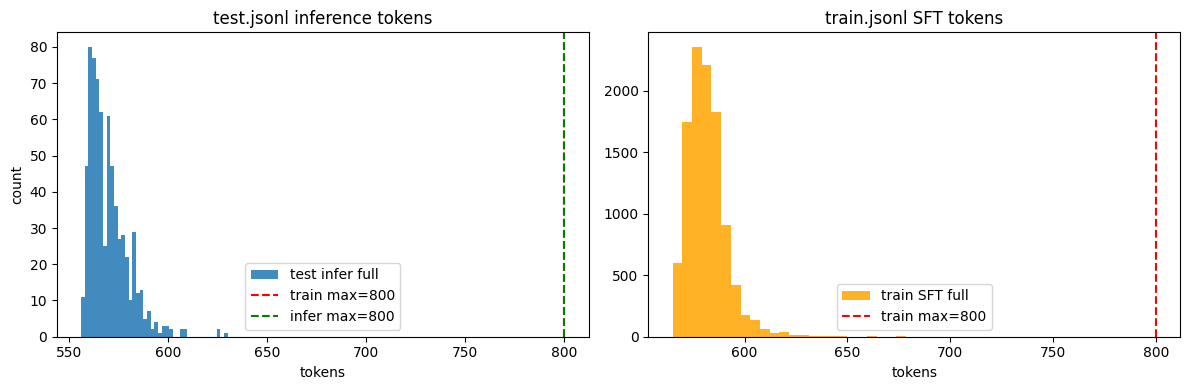

saved F:\GitHub\topicmodeling\tm_research\ensemble\artifacts\metrics\token_length_audit_local.json


,split,idx,mode,n_tokens_full,n_tokens_at_train_max,truncated_at_train_max,chars_prompt_block,chars_text_field,missing_weighted_avg_at_train_max,missing_text_close_at_train_max,missing_stack_close_at_train_max,text_tail_cut_at_train_max,full_has_weighted_avg
0,test,0,infer,586,586,False,493,104,False,False,False,False,True
1,test,1,infer,558,558,False,402,13,False,False,False,False,True
2,test,2,infer,583,583,False,516,127,False,False,False,False,True


In [4]:
import matplotlib.pyplot as plt
from IPython.display import display
from transformers import AutoTokenizer
from tm_research.ensemble.utils_stacking import build_meta_system_prompt

MODEL_NAME = 'google/gemma-2-9b-it'
_lora_meta_path = ARTIFACTS_DIR / 'lora_train_meta.json'
if _lora_meta_path.is_file():
    with open(_lora_meta_path, 'r', encoding='utf-8') as _f:
        _lora_meta = json.load(_f)
    SYSTEM_PROMPT_AUDIT = _lora_meta.get('system_prompt') or weights_payload.get('system_prompt') or build_meta_system_prompt(label_map, weights)
    TRAIN_MAX_LEN = int(_lora_meta.get('max_seq_len', 800))
else:
    SYSTEM_PROMPT_AUDIT = weights_payload.get('system_prompt') or build_meta_system_prompt(label_map, weights)
    TRAIN_MAX_LEN = 800
INFER_MAX_LEN = LOCAL_ZS_MAX_LEN

_tok_src = str(LORA_DIR) if (LORA_DIR / 'tokenizer_config.json').is_file() else MODEL_NAME
_tok_kwargs = {}
if _tok_src == MODEL_NAME:
    if not os.environ.get('HF_TOKEN'):
        raise RuntimeError('HF_TOKEN missing in tm_research/.env. Add it there (Gemma-2 license accepted), or save the adapter tokenizer under artifacts/lora_adapter/.')
    _tok_kwargs['token'] = os.environ['HF_TOKEN']
audit_tok = AutoTokenizer.from_pretrained(_tok_src, **_tok_kwargs)
if audit_tok.pad_token is None:
    audit_tok.pad_token = audit_tok.eos_token


def _user_content(prompt_block: str) -> str:
    return SYSTEM_PROMPT_AUDIT + '\n\n' + prompt_block


def build_infer_chat(prompt_block: str) -> str:
    return audit_tok.apply_chat_template(
        [{'role': 'user', 'content': _user_content(prompt_block)}],
        tokenize=False,
        add_generation_prompt=True,
    )


def build_train_chat(prompt_block: str, completion: str) -> str:
    return audit_tok.apply_chat_template(
        [
            {'role': 'user', 'content': _user_content(prompt_block)},
            {'role': 'assistant', 'content': completion},
        ],
        tokenize=False,
        add_generation_prompt=False,
    )


def _truncate_decode(text: str, max_len: int) -> tuple[list[int], str]:
    enc = audit_tok(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=max_len,
    )
    ids = enc['input_ids']
    return ids, audit_tok.decode(ids, skip_special_tokens=False)


def _prompt_tail_flags(prompt_block: str, decoded: str) -> dict:
    """Flags on the structured prompt region (after system prompt in user turn)."""
    # Decoded chat still contains user payload; marker checks are on full decode.
    text_open = '[TEXT]' in decoded
    text_close = '[/TEXT]' in decoded
    stack_close = '[/STACK]' in decoded
    weighted_close = '[/WEIGHTED_AVG]' in decoded
    orig_text = prompt_block.split('[TEXT]', 1)[-1].split('[/TEXT]', 1)[0].strip() if '[TEXT]' in prompt_block else ''
    in_decoded = orig_text in decoded if orig_text else True
    text_tail_cut = bool(orig_text) and not in_decoded
    return {
        'text_open': text_open,
        'text_close': text_close,
        'stack_close': stack_close,
        'weighted_avg_close': weighted_close,
        'text_tail_cut': text_tail_cut,
    }


def audit_rows(rows, split_name: str, *, train_mode: bool) -> pd.DataFrame:
    records = []
    for row in rows:
        prompt_block = row['prompt']
        if train_mode:
            completion = row.get('completion') or ''
            chat = build_train_chat(prompt_block, completion)
        else:
            chat = build_infer_chat(prompt_block)
        full_ids = audit_tok(chat, add_special_tokens=False)['input_ids']
        n_full = len(full_ids)
        trunc_ids, trunc_dec = _truncate_decode(chat, TRAIN_MAX_LEN)
        n_trunc = len(trunc_ids)
        flags_full = _prompt_tail_flags(prompt_block, chat)
        flags_trunc = _prompt_tail_flags(prompt_block, trunc_dec)
        records.append({
            'split': split_name,
            'idx': row.get('idx'),
            'mode': 'sft_train' if train_mode else 'infer',
            'n_tokens_full': n_full,
            'n_tokens_at_train_max': n_trunc,
            'truncated_at_train_max': n_full > TRAIN_MAX_LEN,
            'chars_prompt_block': len(prompt_block),
            'chars_text_field': len(row.get('text') or ''),
            'missing_weighted_avg_at_train_max': not flags_trunc['weighted_avg_close'],
            'missing_text_close_at_train_max': not flags_trunc['text_close'],
            'missing_stack_close_at_train_max': not flags_trunc['stack_close'],
            'text_tail_cut_at_train_max': flags_trunc['text_tail_cut'],
            'full_has_weighted_avg': flags_full['weighted_avg_close'],
        })
    return pd.DataFrame(records)


def _summarize(df: pd.DataFrame, title: str) -> None:
    n = len(df)
    if n == 0:
        print(title, '(empty)')
        return
    print(f'\n=== {title} (n={n}) ===')
    for col in ('n_tokens_full', 'n_tokens_at_train_max', 'chars_prompt_block', 'chars_text_field'):
        s = df[col]
        print(
            f'  {col}: min={int(s.min())} p50={int(s.median())} p95={int(s.quantile(0.95))} '
            f'max={int(s.max())} mean={s.mean():.1f}'
        )
    trunc = df['truncated_at_train_max']
    print(f'  truncated at train max ({TRAIN_MAX_LEN}): {int(trunc.sum())} ({100 * trunc.mean():.2f}%)')
    for flag in (
        'missing_weighted_avg_at_train_max',
        'missing_text_close_at_train_max',
        'missing_stack_close_at_train_max',
        'text_tail_cut_at_train_max',
    ):
        c = int(df[flag].sum())
        print(f'  {flag}: {c} ({100 * c / n:.2f}%)')
    over = df[df['truncated_at_train_max']].sort_values('n_tokens_full', ascending=False).head(5)
    if len(over):
        print('  top truncated idx (by n_tokens_full):', over['idx'].tolist())


# --- test.jsonl: inference path (same as generate_labels) ---
test_audit = audit_rows(test_rows, 'test', train_mode=False)
_summarize(test_audit, f'test.jsonl — inference chat (add_generation_prompt=True)')

# --- train.jsonl: SFT path (user + assistant, max_length during notebook 06) ---
train_rows_audit = []
with open(META_JSONL_DIR / 'train.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        train_rows_audit.append(json.loads(line))
train_audit = audit_rows(train_rows_audit, 'train', train_mode=True)
_summarize(train_audit, f'train.jsonl — SFT chat (user + assistant)')

# --- inference at eval max_length (LOCAL_ZS_MAX_LEN) on test ---
infer_at_eval = []
for row in test_rows:
    chat = build_infer_chat(row['prompt'])
    full_ids = audit_tok(chat, add_special_tokens=False)['input_ids']
    _, trunc_dec = _truncate_decode(chat, INFER_MAX_LEN)
    flags = _prompt_tail_flags(row['prompt'], trunc_dec)
    infer_at_eval.append({
        'idx': row.get('idx'),
        'n_tokens_full': len(full_ids),
        'truncated_at_infer_max': len(full_ids) > INFER_MAX_LEN,
        'missing_weighted_avg_at_infer_max': not flags['weighted_avg_close'],
        'text_tail_cut_at_infer_max': flags['text_tail_cut'],
    })
infer_eval_df = pd.DataFrame(infer_at_eval)
print(f'\n=== test.jsonl — at inference max_length={INFER_MAX_LEN} ===')
print(
    f'  truncated: {int(infer_eval_df["truncated_at_infer_max"].sum())} '
    f'({100 * infer_eval_df["truncated_at_infer_max"].mean():.2f}%)'
)
print(
    f'  missing [/WEIGHTED_AVG]: {int(infer_eval_df["missing_weighted_avg_at_infer_max"].sum())} '
    f'({100 * infer_eval_df["missing_weighted_avg_at_infer_max"].mean():.2f}%)'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_audit['n_tokens_full'], bins=40, alpha=0.85, label='test infer full')
axes[0].axvline(TRAIN_MAX_LEN, color='red', ls='--', label=f'train max={TRAIN_MAX_LEN}')
axes[0].axvline(INFER_MAX_LEN, color='green', ls='--', label=f'infer max={INFER_MAX_LEN}')
axes[0].set_xlabel('tokens'); axes[0].set_ylabel('count'); axes[0].set_title('test.jsonl inference tokens')
axes[0].legend()
axes[1].hist(train_audit['n_tokens_full'], bins=40, alpha=0.85, color='orange', label='train SFT full')
axes[1].axvline(TRAIN_MAX_LEN, color='red', ls='--', label=f'train max={TRAIN_MAX_LEN}')
axes[1].set_xlabel('tokens'); axes[1].set_title('train.jsonl SFT tokens')
axes[1].legend()
plt.tight_layout()
plt.show()

audit_out = METRICS_DIR / 'token_length_audit_local.json'
summary_payload = {
    'train_max_len': TRAIN_MAX_LEN,
    'infer_max_len': INFER_MAX_LEN,
    'tokenizer_source': _tok_src,
    'test_infer': {
        'n': int(len(test_audit)),
        'truncated_at_train_max': int(test_audit['truncated_at_train_max'].sum()),
        'missing_weighted_avg_at_train_max': int(test_audit['missing_weighted_avg_at_train_max'].sum()),
        'missing_text_close_at_train_max': int(test_audit['missing_text_close_at_train_max'].sum()),
        'text_tail_cut_at_train_max': int(test_audit['text_tail_cut_at_train_max'].sum()),
        'n_tokens_full': test_audit['n_tokens_full'].describe().to_dict(),
    },
    'train_sft': {
        'n': int(len(train_audit)),
        'truncated_at_train_max': int(train_audit['truncated_at_train_max'].sum()),
        'missing_weighted_avg_at_train_max': int(train_audit['missing_weighted_avg_at_train_max'].sum()),
        'missing_text_close_at_train_max': int(train_audit['missing_text_close_at_train_max'].sum()),
        'text_tail_cut_at_train_max': int(train_audit['text_tail_cut_at_train_max'].sum()),
        'n_tokens_full': train_audit['n_tokens_full'].describe().to_dict(),
    },
    'test_at_infer_max': {
        'truncated': int(infer_eval_df['truncated_at_infer_max'].sum()),
        'missing_weighted_avg': int(infer_eval_df['missing_weighted_avg_at_infer_max'].sum()),
    },
}
with open(audit_out, 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)
print('saved', audit_out)
display(test_audit.head(3))


## Classical fusion baselines

These two methods use the **same five probability vectors** as Gemma and the same leakage-controlled OOF protocol. Neither sees the original sentence.

1. **Weighted soft voting** — accuracy-normalized convex combination of the five class-probability vectors, then argmax. Tests *fixed* fusion.
2. **LogReg stacking meta** — multinomial logistic regression on the concatenated OOF probability vector (5 models × 7 classes = 35 features). `C` is selected on val macro-F1. Tests *trainable stacking on probabilities alone*.

Gemma QLoRA is justified as a meta-model only if it beats both: the remaining gap is then from text-conditioned, instance-specific fusion rather than from stacking in general. If it only beats voting but not LogReg, a linear meta-head is enough.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

oof_probs = {m: load_probs(m, 'oof') for m in BASE_MODEL_NAMES}
val_probs = {m: load_probs(m, 'val') for m in BASE_MODEL_NAMES}
test_probs = {m: load_probs(m, 'test') for m in BASE_MODEL_NAMES}

train_df, val_df, test_df, _ = load_splits()
y_train = train_df['label'].map(label_map.label2id).to_numpy()
y_val = val_df['label'].map(label_map.label2id).to_numpy()
y_test_csv = test_df['label'].map(label_map.label2id).to_numpy()
if len(y_test_csv) != len(y_test) or not np.array_equal(y_test_csv, y_test):
    raise ValueError('test.jsonl gold labels must match test CSV order (same as *_test.npy rows).')


def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    print(
        f'\n=== {name} ===\n'
        f'  acc={acc:.4f}  weighted_f1={weighted_f1:.4f}  macro_f1={macro_f1:.4f}  micro_f1={micro_f1:.4f}'
    )
    print(classification_report(
        y_true, y_pred,
        target_names=label_map.class_names,
        zero_division=0,
    ))
    return {
        'name': name,
        'accuracy': acc,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'micro_f1': micro_f1,
    }

results = []
weighted_test = weighted_average(test_probs, weights)
results.append(report('weighted_soft_voting', y_test, weighted_test.argmax(1)))

X_train = stack_prob_features(oof_probs)
X_val = stack_prob_features(val_probs)
X_test = stack_prob_features(test_probs)
logreg_clf, logreg_meta = fit_logreg_meta(X_train, y_train, X_val, y_val, seed=123)
print('logreg_meta selected', logreg_meta)
logreg_pred = logreg_clf.predict(X_test)
results.append(report('logreg_meta', y_test, logreg_pred))

classical_path = METRICS_DIR / 'classical_meta_baselines_local.json'
with open(classical_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print('saved', classical_path)
pd.DataFrame(results)



=== weighted_soft_voting ===
  acc=0.6879  weighted_f1=0.6873  macro_f1=0.6542  micro_f1=0.6879
              precision    recall  f1-score   support

       Anger       0.56      0.50      0.53        40
     Disgust       0.63      0.62      0.63       131
   Enjoyment       0.77      0.78      0.77       193
        Fear       0.62      0.67      0.65        46
       Other       0.64      0.65      0.64       129
     Sadness       0.77      0.76      0.76       116
    Surprise       0.61      0.59      0.60        37

    accuracy                           0.69       692
   macro avg       0.66      0.65      0.65       692
weighted avg       0.69      0.69      0.69       692

logreg_meta selected {'C': 0.25, 'val_macro_f1': 0.635656100824835}

=== logreg_meta ===
  acc=0.6864  weighted_f1=0.6843  macro_f1=0.6459  micro_f1=0.6864
              precision    recall  f1-score   support

       Anger       0.55      0.30      0.39        40
     Disgust       0.59      0.67      0.

,name,accuracy,weighted_f1,macro_f1,micro_f1
0,weighted_soft_voting,0.687861,0.687345,0.654164,0.687861
1,logreg_meta,0.686416,0.684266,0.645929,0.686416


: 

## LoRA meta-model generation

4-bit NF4 + fp16 compute, `device_map='auto'` with ~2GB GPU headroom, batch size 1. First load downloads ~18GB of Gemma-2-9B-it shards into the Hugging Face cache.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from tm_research.ensemble.utils_stacking import build_meta_system_prompt

MODEL_NAME = 'google/gemma-2-9b-it'
if not os.environ.get('HF_TOKEN'):
    raise RuntimeError(
        'HF_TOKEN missing. Add it to tm_research/.env (Gemma-2 license accepted), then re-run the setup cell.'
    )
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for 4-bit Gemma. Install CUDA PyTorch first.')

COMPUTE_DTYPE = torch.float16
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)
tok = AutoTokenizer.from_pretrained(MODEL_NAME, token=os.environ['HF_TOKEN'])
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb,
    device_map='auto',
    max_memory={0: GPU_MAX_MEMORY, 'cpu': CPU_MAX_MEMORY},
    torch_dtype=COMPUTE_DTYPE,
    attn_implementation='eager',
    token=os.environ['HF_TOKEN'],
)
lora_meta_path = ARTIFACTS_DIR / 'lora_train_meta.json'
with open(lora_meta_path, 'r', encoding='utf-8') as f:
    lora_meta = json.load(f)
# Load system prompt from lora_train_meta.json; fall back to weights.json or build fresh.
if lora_meta.get('system_prompt'):
    SYSTEM_PROMPT = lora_meta['system_prompt']
elif weights_payload.get('system_prompt'):
    SYSTEM_PROMPT = weights_payload['system_prompt']
else:
    SYSTEM_PROMPT = build_meta_system_prompt(label_map, weights)
# max_length for LoRA inference matches the training cap for a fair comparison.
LORA_INFER_MAX_LEN = int(lora_meta.get('max_seq_len', 800))
print('SYSTEM_PROMPT:', SYSTEM_PROMPT[:120], '...')
print('LORA_INFER_MAX_LEN:', LORA_INFER_MAX_LEN)
print('COMPUTE_DTYPE:', COMPUTE_DTYPE, 'max_memory', {0: GPU_MAX_MEMORY, 'cpu': CPU_MAX_MEMORY})
model_lora = PeftModel.from_pretrained(base, str(LORA_DIR))
model_lora.eval()
if torch.cuda.is_available():
    print('allocated_gb:', round(torch.cuda.memory_allocated() / 1024**3, 2))


C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in F:\GitHub\topicmodeling\.ensemble_tmp\hf_cache\hub\models--google--gemma-2-9b-it. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Fetching 4 files: 100%|███

In [ ]:
def build_chat(prompt_block):
    return tok.apply_chat_template(
        [{'role': 'user', 'content': SYSTEM_PROMPT + '\n\n' + prompt_block}],
        tokenize=False, add_generation_prompt=True,
    )

@torch.inference_mode()
def generate_labels(model, rows, batch_size=None, max_new_tokens=12, max_length=None):
    """Generate label predictions for a list of meta-dataset rows.

    ``max_length`` controls tokenizer truncation. On 12GB both LoRA and
    zero-shot use the training cap (``LORA_INFER_MAX_LEN`` / ``LOCAL_ZS_MAX_LEN``).
    """
    if batch_size is None:
        batch_size = INFER_BATCH
    if max_length is None:
        max_length = LORA_INFER_MAX_LEN
    preds = []
    for i in range(0, len(rows), batch_size):
        batch = rows[i:i+batch_size]
        chats = [build_chat(r['prompt']) for r in batch]
        enc = tok(chats, return_tensors='pt', padding=True, truncation=True, max_length=max_length).to(model.device)
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=False, temperature=0.0,
            pad_token_id=tok.pad_token_id,
        )
        gen = out[:, enc['input_ids'].shape[1]:]
        decoded = tok.batch_decode(gen, skip_special_tokens=True)
        for txt in decoded:
            lab = parse_label_from_completion(txt, label_map)
            preds.append(lab)
        if i % (batch_size * 10) == 0:
            print(f'  {i}/{len(rows)}')
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return preds

lora_pred_labels = generate_labels(model_lora, test_rows, batch_size=INFER_BATCH, max_length=LORA_INFER_MAX_LEN)
fallback = weighted_test.argmax(1)
lora_pred_ids = np.array([
    label_map.label2id[lab] if lab in label_map.label2id else int(fallback[i])
    for i, lab in enumerate(lora_pred_labels)
])
results.append(report('lora_gemma_meta', y_test, lora_pred_ids))


## Zero-shot Gemma baseline (no LoRA, same prompts)

Uses `LOCAL_ZS_MAX_LEN` (800) instead of Colab's 2048 so the 12GB card does not OOM. Set `RUN_ZERO_SHOT = False` in the setup cell to skip this pass.


In [ ]:
model_lora = model_lora.unload() if hasattr(model_lora, 'unload') else None
torch.cuda.empty_cache()
if RUN_ZERO_SHOT:
    zs_pred_labels = generate_labels(
        base, test_rows, batch_size=INFER_BATCH, max_length=LOCAL_ZS_MAX_LEN,
    )
    zs_pred_ids = np.array([
        label_map.label2id[lab] if lab in label_map.label2id else int(fallback[i])
        for i, lab in enumerate(zs_pred_labels)
    ])
    results.append(report('zero_shot_gemma', y_test, zs_pred_ids))
else:
    print('Skipping zero-shot (RUN_ZERO_SHOT=False)')


## Confusion matrix for the LoRA meta-model

In [ ]:
cm = confusion_matrix(y_test, lora_pred_ids, labels=list(range(label_map.num_classes)))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_map.class_names, yticklabels=label_map.class_names,
)
plt.xlabel('Predicted'); plt.ylabel('Gold'); plt.title('LoRA-Gemma meta-model (test, local)')
plt.tight_layout()
from pathlib import Path
out_dir = Path(REPO_ROOT) / 'Confusion_matrix'
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / 'ensemble_llm_meta_local.png'
plt.savefig(out_png, dpi=150)
plt.show()
print('saved', out_png)


In [ ]:
summary_path = METRICS_DIR / 'ensemble_summary_local.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print('saved', summary_path)
pd.DataFrame(results).sort_values('weighted_f1', ascending=False).reset_index(drop=True)


## What the numbers support

Ranking is by weighted F1 (the paper metric). The paragraph below is chosen from the observed order so the notebook does not over-claim.

In [ ]:
EPS = 0.005  # 0.5 pp treated as a tie
by_name = {r['name']: r for r in results}
ranked = sorted(results, key=lambda r: (r.get('weighted_f1', 0.0), r['macro_f1']), reverse=True)
print('Ranking (weighted F1):')
for i, r in enumerate(ranked, 1):
    print(
        f"  {i}. {r['name']:24s}  "
        f"acc={r['accuracy']:.4f}  wF1={r.get('weighted_f1', float('nan')):.4f}  "
        f"mF1={r['macro_f1']:.4f}"
    )

gemma = by_name.get('lora_gemma_meta')
logreg = by_name.get('logreg_meta')
vote = by_name.get('weighted_soft_voting')

if gemma and logreg and vote:
    g, l, v = gemma['weighted_f1'], logreg['weighted_f1'], vote['weighted_f1']
    if g > l + EPS and l >= v - EPS:
        paragraph = (
            'Gemma beats LogReg, which is at least as strong as voting. '
            'Fixed fusion is not enough, and a linear stacking head on probability '
            'vectors is not enough either. The remaining gap supports text-conditioned, '
            'instance-specific fusion in the QLoRA meta-model.'
        )
    elif abs(g - l) <= EPS:
        paragraph = (
            'Gemma and LogReg are tied within 0.5 pp weighted F1. A linear stacking '
            'head on the same probability vectors is enough; these numbers do not '
            'justify the LLM as a meta-model.'
        )
    elif l > g + EPS:
        paragraph = (
            'LogReg stacking beats Gemma. Trainable fusion on probability vectors '
            'alone is stronger than the LLM meta-model; do not claim text-conditioned '
            'instance-specific fusion from this run.'
        )
    elif v >= g - EPS and v >= l - EPS:
        paragraph = (
            'Weighted soft voting wins or ties the trainable heads. Even fixed '
            'fusion suffices; neither LogReg nor Gemma is justified as a meta-learner '
            'on this test set.'
        )
    else:
        paragraph = (
            'See the ranking above. Gemma is justified as a meta-model only if it '
            'beats both weighted soft voting and LogReg stacking on weighted F1.'
        )
    print('\n' + paragraph)
else:
    print(
        '\nRun the LoRA / zero-shot cells to compare Gemma against the classical '
        'baselines. CPU results are in artifacts/metrics/classical_meta_baselines_local.json.'
    )


In [ ]:
from tm_research.ensemble.utils_io import push_artifacts_to_persistent
push_artifacts_to_persistent()